<a href="https://colab.research.google.com/github/ayesha-tubassum/fdlkdjg/blob/main/unsupervised_k_means(wholesale_custmer_data).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("/content/Wholesale customers data.csv")

df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [3]:
df.shape

(440, 8)

In [4]:
df.columns

Index(['Channel', 'Region', 'Fresh', 'Milk', 'Grocery', 'Frozen',
       'Detergents_Paper', 'Delicassen'],
      dtype='object')

In [13]:
X = df.drop(['Channel', 'Region'], axis=1)
print(X.head())

KeyError: "['Channel', 'Region'] not found in axis"

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Fresh             440 non-null    int64
 1   Milk              440 non-null    int64
 2   Grocery           440 non-null    int64
 3   Frozen            440 non-null    int64
 4   Detergents_Paper  440 non-null    int64
 5   Delicassen        440 non-null    int64
dtypes: int64(6)
memory usage: 20.8 KB


In [15]:
df.isnull().sum()

,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


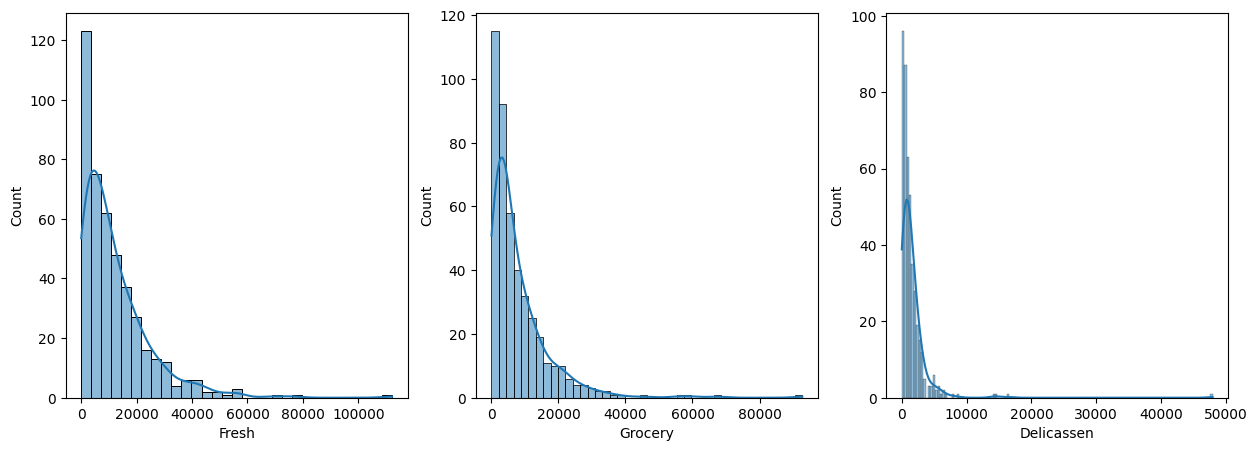

In [19]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df['Fresh'], kde=True)

plt.subplot(1,3,2)
sns.histplot(df['Grocery'], kde=True)

plt.subplot(1,3,3)
sns.histplot(df['Delicassen'], kde=True)

plt.show()

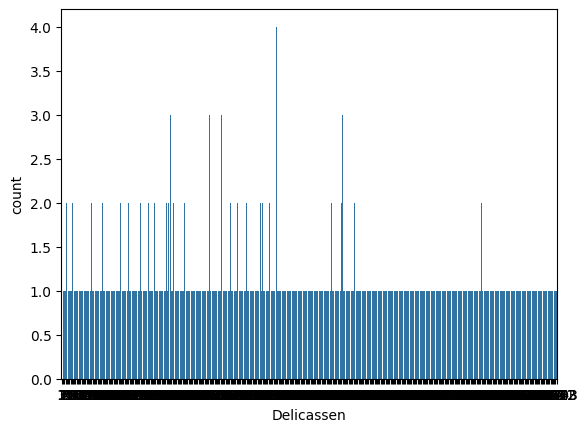

In [20]:
sns.countplot(x='Delicassen', data=df)
plt.show()

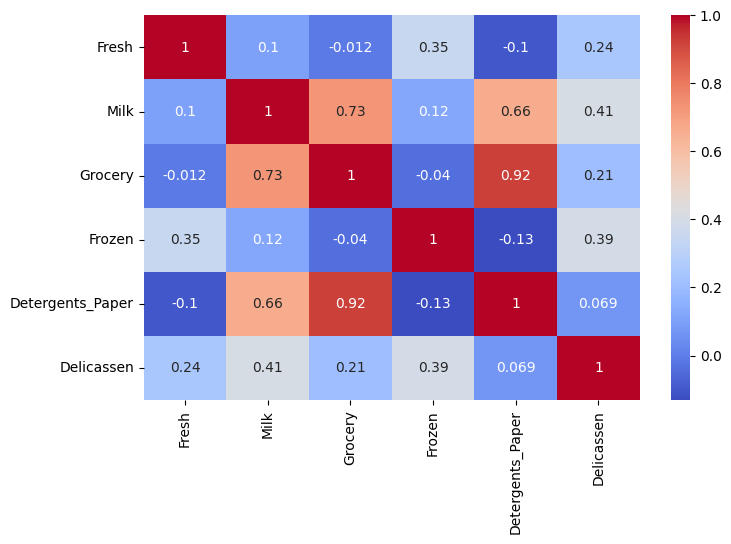

In [21]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.show()

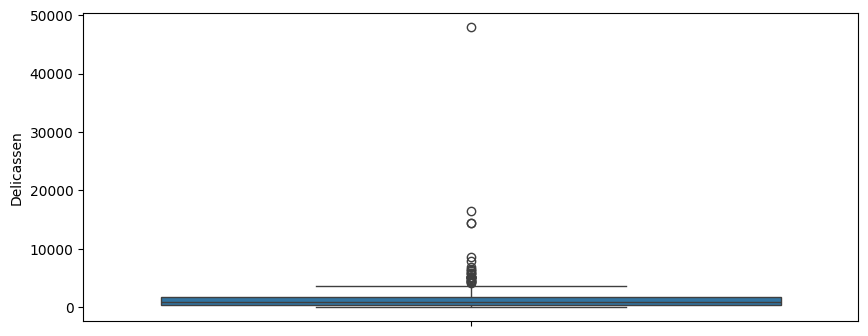

In [23]:
plt.figure(figsize=(10,4))

sns.boxplot(df['Delicassen'])

plt.show()

In [24]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

In [25]:
X_scaled[:5]

array([[ 0.05293319,  0.52356777, -0.04111489, -0.58936716, -0.04356873,
        -0.06633906],
       [-0.39130197,  0.54445767,  0.17031835, -0.27013618,  0.08640684,
         0.08915105],
       [-0.44702926,  0.40853771, -0.0281571 , -0.13753572,  0.13323164,
         2.24329255],
       [ 0.10011141, -0.62401993, -0.3929769 ,  0.6871443 , -0.49858822,
         0.09341105],
       [ 0.84023948, -0.05239645, -0.07935618,  0.17385884, -0.23191782,
         1.29934689]])

In [26]:
wcss = []

for i in range(1,11):

    km = KMeans(
        n_clusters=i,
        random_state=42
    )

    km.fit(X_scaled)

    wcss.append(km.inertia_)

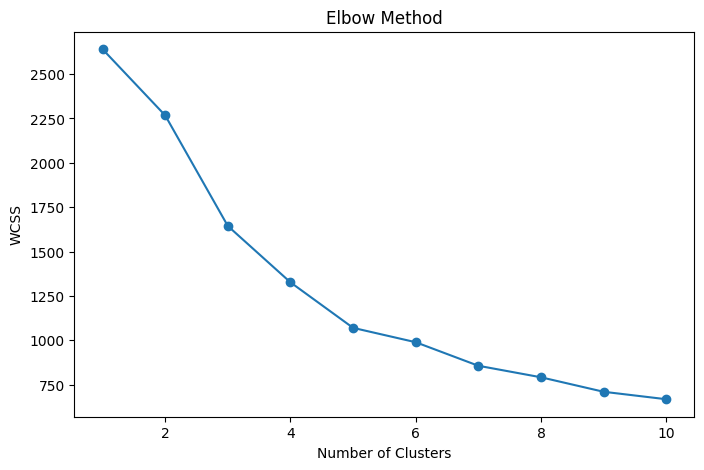

In [27]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [37]:
km = KMeans(
    n_clusters=3,
    random_state=42
)

In [38]:
y_means = km.fit_predict(X_scaled)

In [39]:
df['Cluster'] = y_means

In [40]:
df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,12669,9656,7561,214,2674,1338,0
1,7057,9810,9568,1762,3293,1776,0
2,6353,8808,7684,2405,3516,7844,0
3,13265,1196,4221,6404,507,1788,0
4,22615,5410,7198,3915,1777,5185,1


In [41]:
cluster_profile = df.groupby('Cluster').mean()

cluster_profile

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,8935.500000,4228.528571,5848.034286,2167.231429,1913.605714,1102.120000
1,34540.113208,5860.358491,6122.622642,9841.735849,981.471698,3664.245283
2,8704.864865,20534.405405,30466.243243,1932.621622,14758.837838,2459.351351


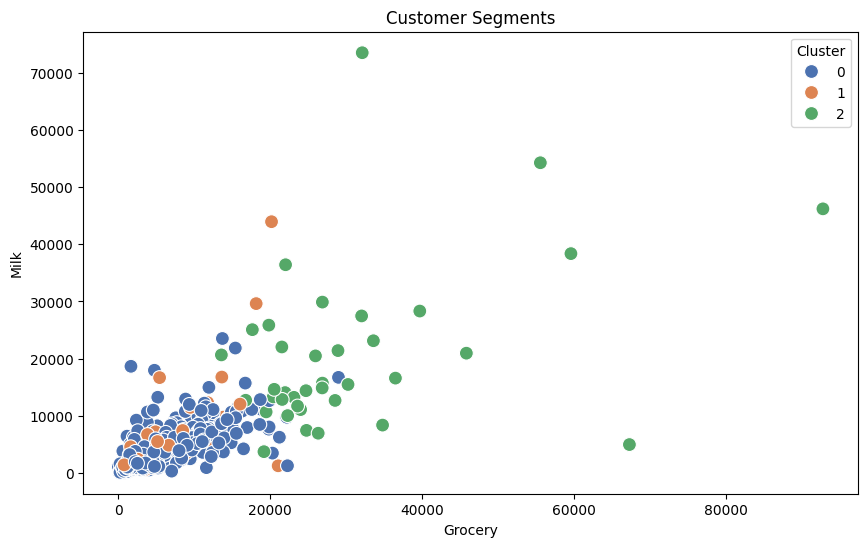

In [49]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Grocery'],
    y=df['Milk'],
    hue=df['Cluster'],
    palette='deep',
    s=100
)

plt.title("Customer Segments")
plt.xlabel("Grocery")
plt.ylabel("Milk")

plt.show()

In [50]:
score = silhouette_score(X_scaled, y_means)

print("Silhouette Score:", score)

Silhouette Score: 0.4582633767207058


In [34]:
for k in range(2,11):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K={k}, Score={score}")

K=2, Score=0.3998278091730005
K=3, Score=0.4582633767207058
K=4, Score=0.34939129340421093
K=5, Score=0.36890127429678043
K=6, Score=0.2762464573058837
K=7, Score=0.276678268663421
K=8, Score=0.32366546538940916
K=9, Score=0.29453704649783113
K=10, Score=0.22876866444760022
